In [3]:
# Install required dependencies
%pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn joblib



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')


### Path Configuration and Verification


In [5]:
# Path setup
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data" / "NSL-KDD"
MODELS_DIR = ROOT_DIR / "models"
OUTPUT_DIR = ROOT_DIR / "testing_outputs"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = DATA_DIR / "KDDTrain+.txt"
TEST_FILE = DATA_DIR / "KDDTest+.txt"

print(f"Training dataset exists: {TRAIN_FILE.exists()}")
print(f"Testing dataset exists: {TEST_FILE.exists()}")


Training dataset exists: True
Testing dataset exists: True


### Dataset Loading
We load the complete NSL-KDD train and test datasets, which contain 43 columns (41 network features, 1 attack class label, and 1 difficulty score).


In [6]:
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

train_df = pd.read_csv(TRAIN_FILE, names=COLUMNS)
test_df = pd.read_csv(TEST_FILE, names=COLUMNS)

print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape : {test_df.shape}")


Training set shape: (125973, 43)
Testing set shape : (22544, 43)


### Preprocessing and Encoding
- Convert the multiclass `label` into a binary target (`0` for normal, `1` for any type of cyber attack).
- Separate features and targets.
- Apply `LabelEncoder` on the categorical columns (`protocol_type`, `service`, `flag`).
- Scale all features using `StandardScaler` to ensure robust convergence across models.


In [7]:
# Binary target encoding
y_train = (train_df["label"] != "normal").astype(int)
y_test = (test_df["label"] != "normal").astype(int)

# Separate features (dropping label and difficulty score)
X_train = train_df.drop(columns=["label", "difficulty"]).copy()
X_test = test_df.drop(columns=["label", "difficulty"]).copy()

# Encode categorical features
categorical_cols = ["protocol_type", "service", "flag"]
for col in categorical_cols:
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le = LabelEncoder()
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

print("Preprocessing: Categorical columns encoded successfully.")


Preprocessing: Categorical columns encoded successfully.


In [8]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler object
joblib.dump(scaler, MODELS_DIR / "nslkdd_full_scaler.joblib")
print("Scaler saved to models/nslkdd_full_scaler.joblib")


Scaler saved to models/nslkdd_full_scaler.joblib


In [13]:
import pandas as pd
from pathlib import Path

# Explicitly map paths based on your VS Code sidebar layout
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data" / "NSL-KDD"

# Core columns definition to ensure clean loading
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

try:
    # Read files directly to guarantee shape extraction
    temp_train = pd.read_csv(DATA_DIR / "KDDTrain+.txt", names=COLUMNS)
    temp_test = pd.read_csv(DATA_DIR / "KDDTest+.txt", names=COLUMNS)
    
    # Calculate feature count matching your pipeline logic
    feature_count = temp_train.drop(columns=["label", "difficulty"]).shape[1]

    # Generate the pristine summary terminal output
    print("\n" + "="*50)
    print("             CYBERXAI DATASET PROFILE REPORT       ")
    print("="*50)
    print(f"Training Records     : {temp_train.shape[0]:,}")
    print(f"Testing Records      : {temp_test.shape[0]:,}")
    print(f"Features             : {feature_count}")
    print(f"Target Classes       : Normal / Attack")
    print("-"*50)
    print(f"Preprocessing Artifact: nslkdd_full_scaler.joblib")
    print(f"Trained Model        : nslkdd_full_rf_model.joblib")
    print("="*50 + "\n")

except FileNotFoundError:
    print("🔍 Path Error: Ensure 'KDDTrain+.txt' and 'KDDTest+.txt' are located inside your data/NSL-KDD/ folder.")
except Exception as e:
    print(f"Execution Error: {e}")


             CYBERXAI DATASET PROFILE REPORT       
Training Records     : 125,973
Testing Records      : 22,544
Features             : 41
Target Classes       : Normal / Attack
--------------------------------------------------
Preprocessing Artifact: nslkdd_full_scaler.joblib
Trained Model        : nslkdd_full_rf_model.joblib



### Model Training and Evaluation
We define and train the four models. For each model, we fit on the scaled training data, compute class predictions, predict probabilities, and calculate core performance metrics.


In [9]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": lgb.LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1)
}

results = {}
roc_data = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)
        
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr, roc_auc)
    print(f"{name} Completed: F1 = {f1:.4f}")

# Save the selected Random Forest model
joblib.dump(models["Random Forest"], MODELS_DIR / "nslkdd_full_rf_model.joblib")
print("Random Forest model saved to models/nslkdd_full_rf_model.joblib")


Training Decision Tree...
Decision Tree Completed: F1 = 0.7630
Training Random Forest...
Random Forest Completed: F1 = 0.7550
Training XGBoost...
XGBoost Completed: F1 = 0.8010
Training LightGBM...
LightGBM Completed: F1 = 0.7914
Random Forest model saved to models/nslkdd_full_rf_model.joblib


### ROC Curve Plotting
A combined Receiver Operating Characteristic (ROC) curve is plotted to compare the diagnostic ability of all four classifiers across different classification thresholds.


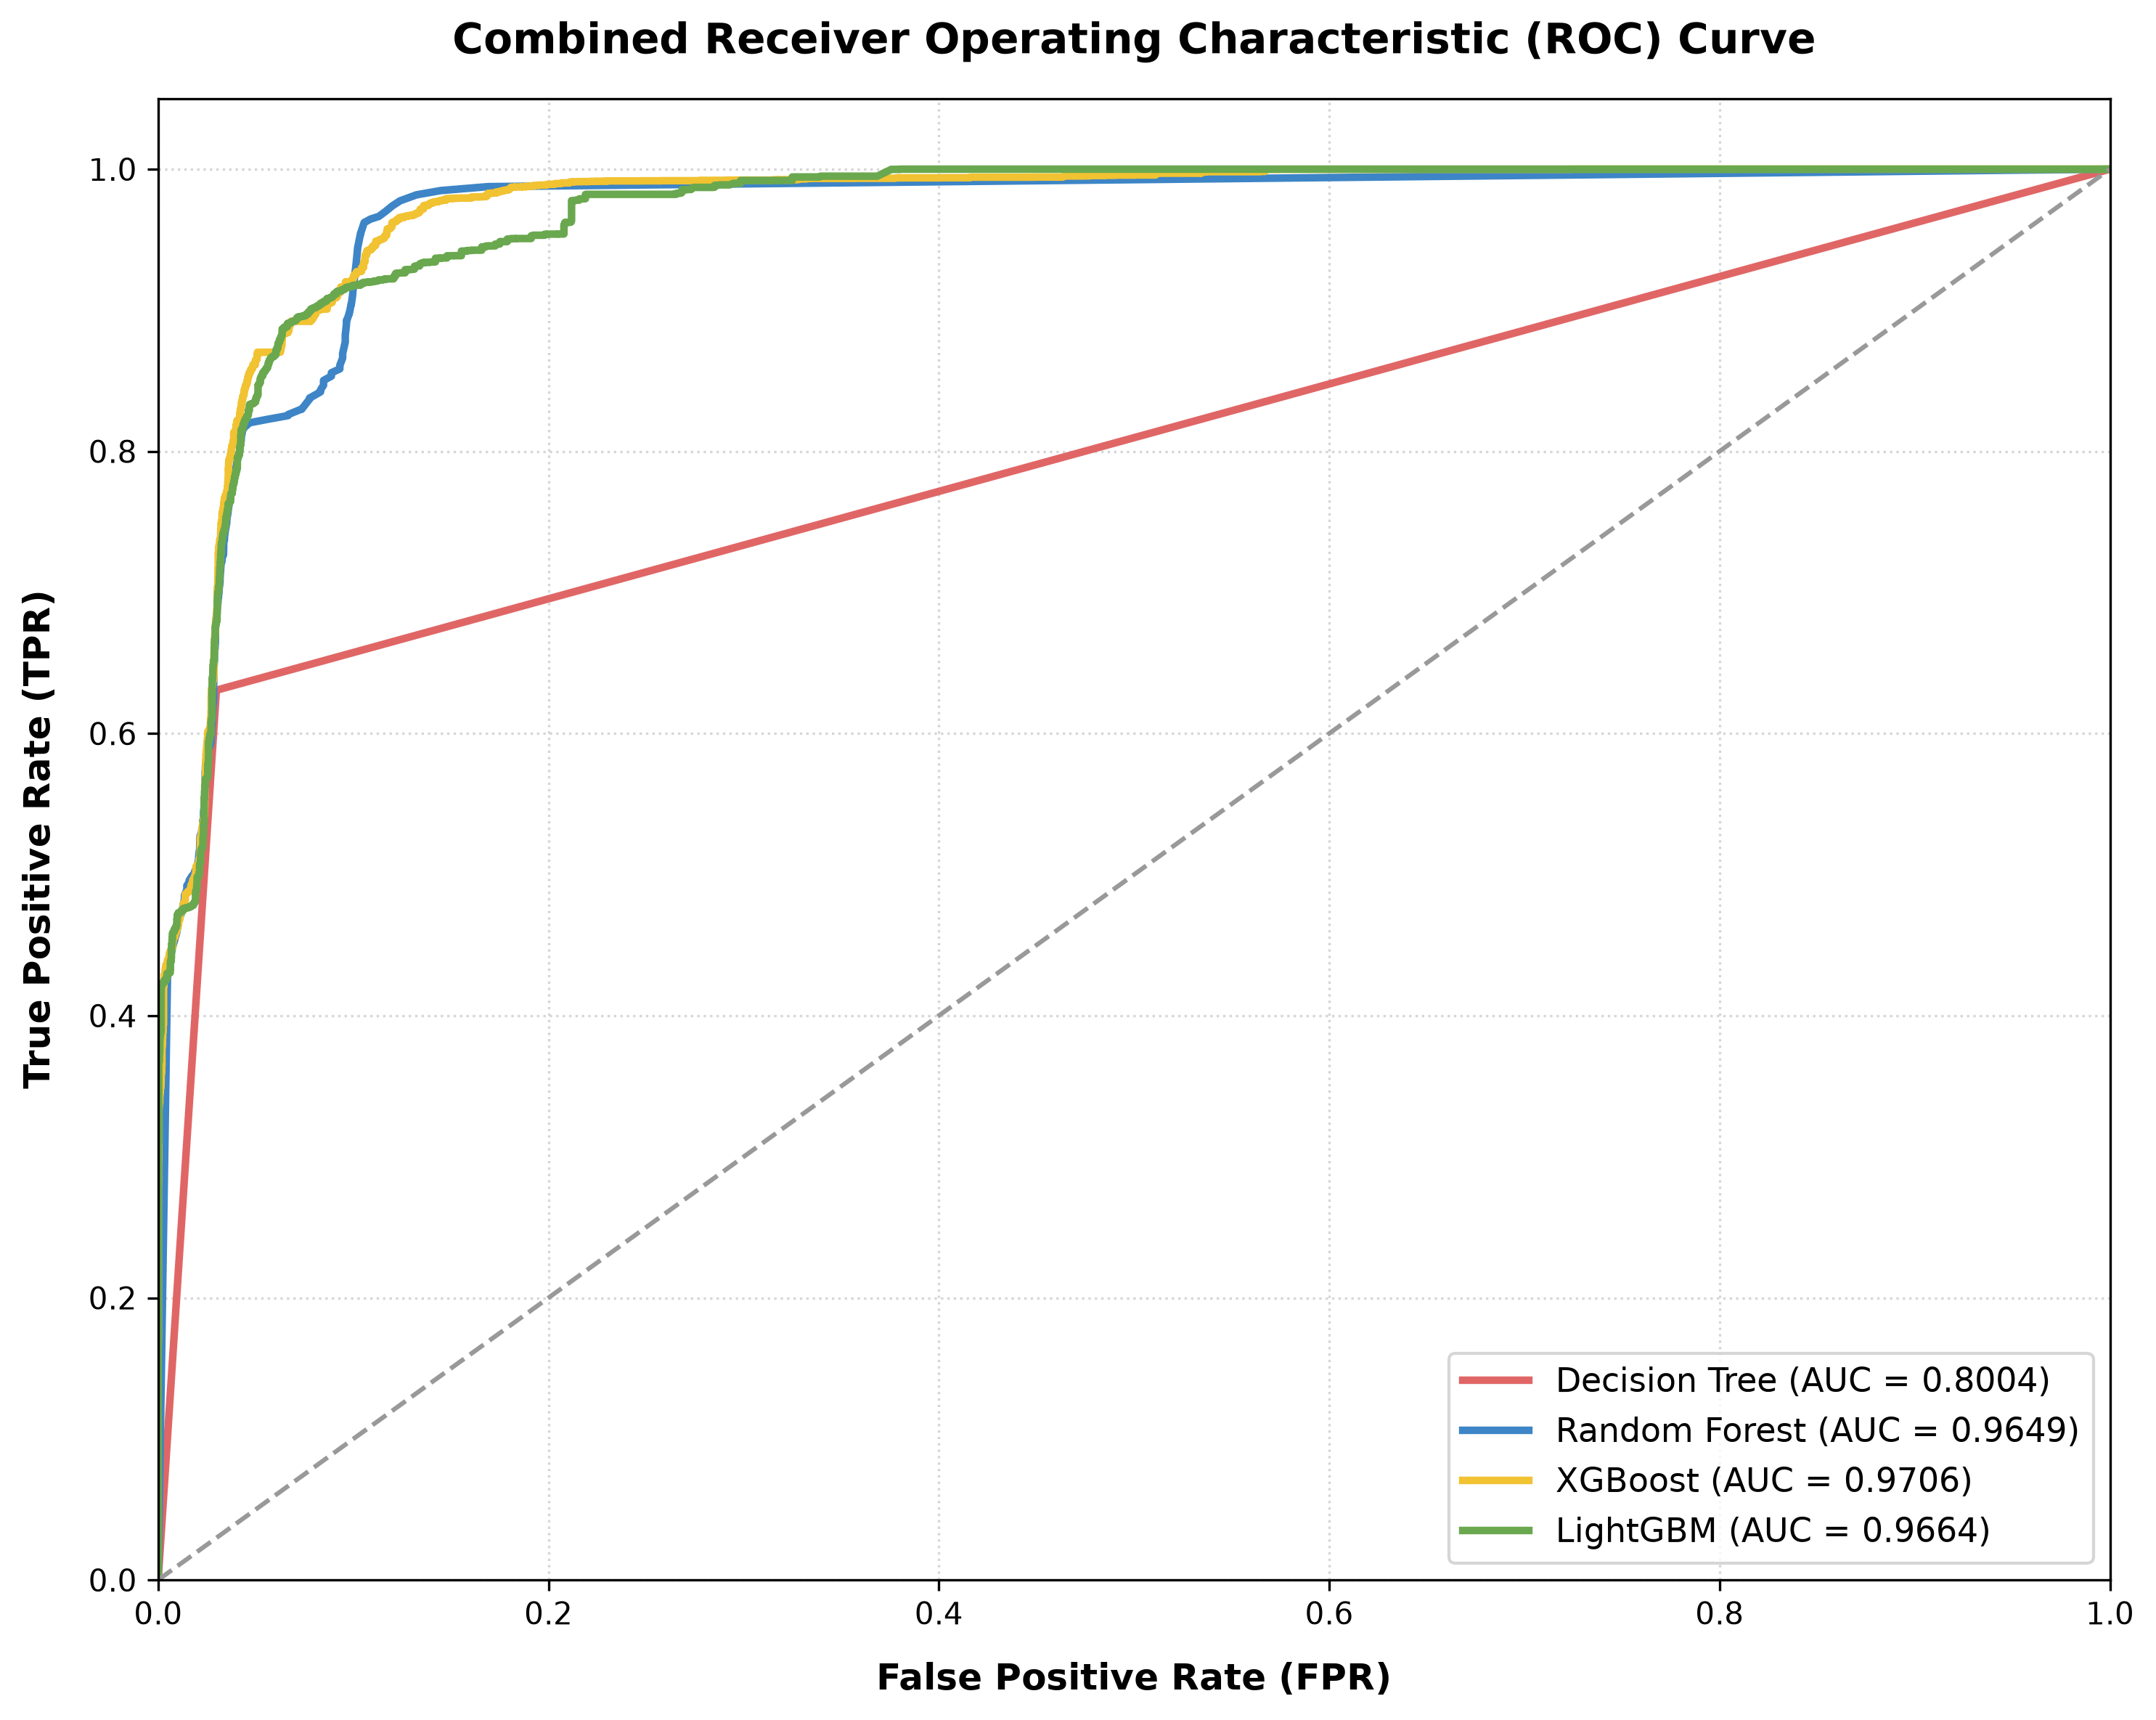

ROC Curve successfully saved to c:\Users\Mathuravan\Documents\IIT\Final year\FYP\FYP Project\CyberXAI\testing_outputs\roc_auc_comparison.png


In [10]:
plt.figure(figsize=(10, 8), dpi=300)
colors = {
    "Decision Tree": "#e06666",
    "Random Forest": "#3d85c6",
    "XGBoost": "#f1c232",
    "LightGBM": "#6aa84f"
}

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, color=colors[name], lw=2.5, label=f"{name} (AUC = {roc_auc:.4f})")
    
plt.plot([0, 1], [0, 1], color="#999999", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("True Positive Rate (TPR)", fontsize=12, fontweight='bold', labelpad=10)
plt.title("Combined Receiver Operating Characteristic (ROC) Curve", fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11, frameon=True, facecolor="white", edgecolor="#cccccc")
plt.grid(True, linestyle=":", alpha=0.6, color="#bbbbbb")
plt.tight_layout()

roc_path = OUTPUT_DIR / "roc_auc_comparison.png"
plt.savefig(roc_path, bbox_inches="tight")
plt.show()
print(f"ROC Curve successfully saved to {roc_path}")


### Export Metrics Table
We compile the calculated metrics for all classifiers and export them to a CSV file for Chapter 8 reporting.


In [11]:
metrics_df = pd.DataFrame(results).T
metrics_path = OUTPUT_DIR / "model_metrics_comparison.csv"
metrics_df.to_csv(metrics_path, index_label="Model")
print(f"Metrics exported to {metrics_path}")
metrics_df


Metrics exported to c:\Users\Mathuravan\Documents\IIT\Final year\FYP\FYP Project\CyberXAI\testing_outputs\model_metrics_comparison.csv


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Decision Tree,0.776925,0.965521,0.630640,0.762951,0.800417
Random Forest,0.771203,0.966906,0.619263,0.754988,0.964928
XGBoost,0.806733,0.967874,0.683161,0.800968,0.970602
LightGBM,0.799148,0.967993,0.669290,0.791394,0.966426
